# Day 2

## Data exploration, cleaning, and feature engineering

Notebook prepared by Nuno R. C. Gomes, IEEC/ICE-CSIC | v20260504

###### Cerdanyola del Vallès, Barcelona, 18-22 May 2026

----

### 📦 Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from scipy import stats

### ⚙️ Configuration

In [2]:
# set visualisation style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Confusion matrix

Let us consider the confusion matrix for **dog** image recognition.

Index | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12
--- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | ---
Actual/True | dog | cat | cat | cat | dog | cat | dog | dog | dog | dog | dog | cat
Predicted   | dog | cat | dog | dog | dog | cat | dog | cat | dog | dog | dog | cat
Result      |     |     |     |     |     |     |     |     |     |     |     |   

- Actual dogs: 
- Actual not dogs: 
- True positives (TP):
- False positive (FP): 
- True negatives (TN):
- False negatives (FN): 

|      |          | Predicted | Predicted |
| ---  | ---      | ---       | ---       |
|      |          | Positive  | Negative  |
| True | Positive |           |           |
| True | Negative |           |           |

- Accuracy = 
- Precision = 
- Recall = 
- F1-score = 

##### Create the confusion matrix for this case and plot it using `sns.heatmap()`.

##### Print the classifications report based on confusion metrics.
> Hint: use the function `classification_report()`.

### 🧹 Data cleaning

We are going to use the Titanic data set to understand and practice some standard data cleaning steps.

In [ ]:
# read titanic data

# get info of data

# get overall view of data frame


In [ ]:
# find duplicated cases


In [ ]:
# find columns with categorical data types


In [ ]:
# find how many unique values in the categorical variables


In [ ]:
# calculate percentage of missing values


In [ ]:
# drop irrelevant columns or those with lots of missing values


In [ ]:
# detect outliers for age with a box-plot


The following code attempts to remove outliers and impute missing values.
It contains several bad practices and some inconsistencies.
Can you find them?

In [ ]:
# calculate outlier boundaries and remove them
mean = df1['Age'].mean()
std = df1['Age'].std()

lower_bound = mean - 2*std
upper_bound = mean + 2*std

df2 = df1[(df1['Age'] >= lower_bound) & (df1['Age'] <= upper_bound)]

In [ ]:
# impute missing data
df3 = df2.fillna(df2['Age'].mean())
df3.isnull().sum()

mean = df3['Age'].mean()
std = df3['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print('Lower Bound :', lower_bound)
print('Upper Bound :', upper_bound)

df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]

In [ ]:
# define X as the set of predictors

# define y as the target variable


Can you come up with a better strategy?

### 🗂️ Data set

We will use the "Palmer Penguins" data set (a modern alternative to Iris).
It contains morphological measurements for three penguin species.

In [ ]:
# path to save CSV
file_path = Path("data/penguins.csv")

# check if file exists
if file_path.exists():
  # load from local CSV
  df = pd.read_csv(file_path)
  print(f"Loaded data set from {file_path}")
else:
  # ensure data/ directory exists (create it otherwise)
  file_path.parent.mkdir(parents=True, exist_ok=True)
  # url of data set
  url = (
    "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/master/"
    "inst/extdata/penguins.csv"
  )
  # read CSV from web
  df = pd.read_csv(url)
  # save CSV to data/
  df.to_csv(file_path, index=False)
  print(f"Saved data set to {file_path}")

### 🔍 Exploratory data analysis (EDA)

In this section, we explore the data set to understand its structure, distributions, and relationships between variables.
Through visualisations and summary statistics, we aim to uncover patterns, spot anomalies, and generate insights that will guide subsequent analysis and modelling.

In [4]:
print("--- Data set info ---")
df.info()

--- Data set info ---
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


In [5]:
print("\n--- Summary statistics ---")
df.describe()


--- Summary statistics ---


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


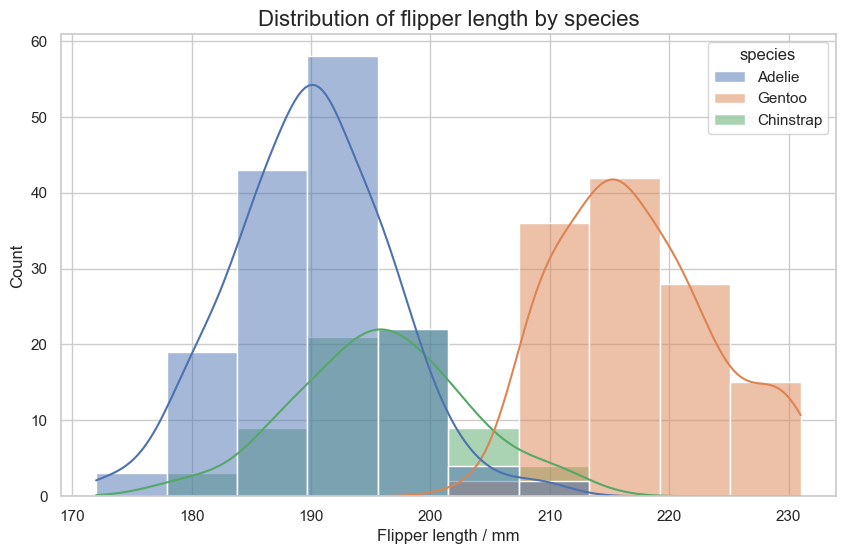

In [6]:
# visualise distributions
sns.histplot(data=df, x="flipper_length_mm", hue="species", kde=True)
plt.title("Distribution of flipper length by species", fontsize=16)
plt.xlabel("Flipper length / mm");

### 🔧 Data Wrangling
In this section, we clean and prepare the data set by handling missing values, treating outliers, creating new features, and applying PCA for dimensionality reduction.
These steps ensure our data are reliable, meaningful, and ready for analysis or modelling.

#### Missing values

In [ ]:
print("\n--- Missing values count ---")
# your code here...


--- Missing values count ---


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

#### Data imputation

In [ ]:
# simple imputation for numerical columns
# use median to avoid outlier influence
df['bill_length_mm'] = df['bill_length_mm'].fillna(
  df['bill_length_mm'].median()
)

df['bill_depth_mm'] = # complete me

df['flipper_length_mm'] = # complete me

df['body_mass_g'] = # complete me

df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,NaN,2007
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.80,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.50,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.60,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.80,19.0,210.0,4100.0,male,2009


In [9]:
df.isnull().sum()

species               0
island                0
bill_length_mm        0
bill_depth_mm         0
flipper_length_mm     0
body_mass_g           0
sex                  11
year                  0
dtype: int64

In [ ]:
# drop rows with missing categorical labels (species)
# your code goes here
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,NaN,2007
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.80,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.50,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.60,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.80,19.0,210.0,4100.0,male,2009


#### Handling outliers

In [11]:
# calculate Z-scores for bill depth
z_scores = np.abs(stats.zscore(df['bill_depth_mm'].dropna()))
# filter out rows where z-score > 3 (anomalies)
df_clean = df[
  (
    np.abs(stats.zscore(df.select_dtypes(include=[np.number]))) < 3
  ).all(axis=1)
]
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,NaN,2007
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.80,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.50,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.60,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.80,19.0,210.0,4100.0,male,2009


#### Feature engineering and scaling

In [12]:
# make copy of data frame
df0 = df.copy()

# create new feature: body mass [kg]
df['body_mass_kg'] = df['body_mass_g'] / 1000

# one-hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=['island', 'sex'])

# scaling numerical features
scaler = StandardScaler()
num_cols = [
  'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_kg'
]
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

# first five rows after preprocessing
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,body_mass_kg
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,male,2007,3.75
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,female,2007,3.80
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,female,2007,3.25
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,NaN,2007,4.05
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,female,2007,3.45


#### Dimensionality reduction (PCA)


Explained variance ratio by component:
[0.68837221 0.19313603]


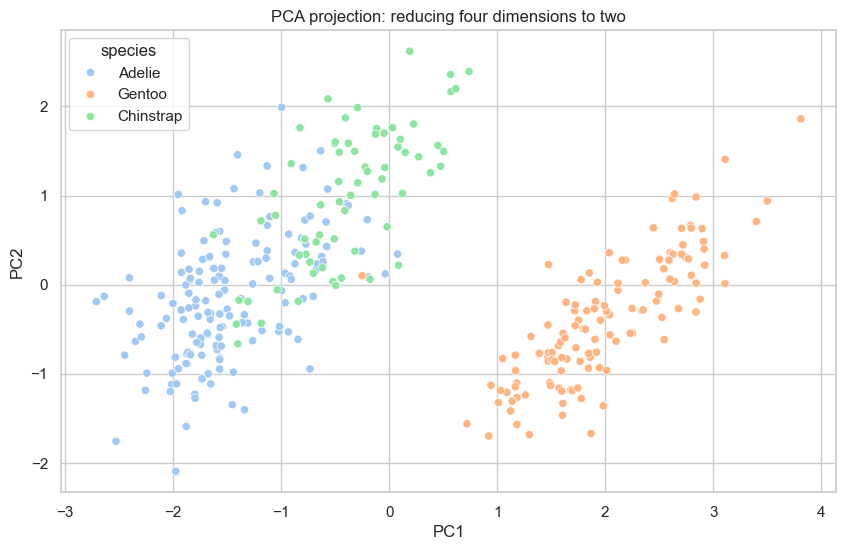

In [ ]:
# prepare data for PCA (drop non-numeric and target)
features = df_encoded[num_cols]
pca = PCA(n_components=2)
principal_components = pca.fit_transform(features)

# create data frame for visualisation
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
df_pca['species'] = df['species'].values

# visualise PCA projection
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='species', palette='pastel')
plt.title("PCA projection: reducing four dimensions to two");

print("\nExplained variance ratio by component:")
print(pca.explained_variance_ratio_)

Can you find which of the raw features make up, for instance, PC1?